# Pixel-wise Logistic Regression для случайных образов

## tl;dr

- Источник результатов: неизменяемый run `artifacts/experiments/logistic-regression/f515948b6bf5af55/`; обучение в notebook не повторяется.
- На 39 блоках от 7 удержанных субъектов средняя balanced accuracy по 36 пикселям равна **0.5100**. 95% cluster-bootstrap interval по субъектам: **[0.4964, 0.5211]**, то есть шанс 0.5 не исключён.
- Точных реконструкций 6x6 нет. Средний sample IoU равен **0.3353**, micro IoU — **0.3346**, а Hamming loss — **0.4858** (17.49 ошибочных пикселя из 36).
- Частотный baseline имеет меньший Hamming loss (0.4758) и лучший Brier score (0.251 против 0.334), поэтому EEG-модель не превосходит простую частотную реконструкцию.
- `lbp` был выбран корректно только по outer-train CV, но итоговый результат не подтверждает полезную межсубъектную реконструкцию. Это воспроизводимый отрицательный baseline.


## Context & Methods

Задача состоит из 36 независимых бинарных классификаторов: один полный интервал моторного/визуального воображения `[0.5, 15.5)` соответствует одной 6x6 бинарной картинке. Используются только `Data_Pattern/patt` блоки с `type="random"`.

### Key Assumptions

- Единица внешнего разбиения — субъект; 26 субъектов в train и 7 в test не пересекаются.
- Основная метрика — невзвешенное среднее per-pixel balanced accuracy.
- Bootstrap ресэмплирует целые кластеры субъектов с возвращением. Draw отбрасывается, если хотя бы один пиксель теряет один из классов.
- Baseline probabilities оцениваются на том же test set; seeded Bernoulli фиксирован `random_state=42`.
- Joblib pipelines загружаются только через явную локальную trust boundary после проверки manifest. Notebook не вызывает `.fit()`.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from experiments.logistic_regression import (
    bootstrap_subject_mean_balanced_accuracy,
    build_non_eeg_baselines,
    evaluate_prediction_matrix,
    load_experiment_run,
)

RUN_DIR = PROJECT_ROOT / "artifacts/experiments/logistic-regression/f515948b6bf5af55"
RUN_ID = RUN_DIR.name

COLORS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
    "blue": "#A3BEFA",
    "blue_dark": "#2E4780",
    "gold": "#FFE15B",
    "gold_dark": "#736422",
    "neutral": "#C5CAD3",
    "neutral_dark": "#464C55",
    "orange": "#F0986E",
    "orange_dark": "#804126",
}

plt.rcParams.update({
    "figure.facecolor": COLORS["surface"],
    "axes.facecolor": COLORS["panel"],
    "axes.edgecolor": COLORS["axis"],
    "axes.labelcolor": COLORS["ink"],
    "text.color": COLORS["ink"],
    "xtick.color": COLORS["muted"],
    "ytick.color": COLORS["muted"],
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def add_header(fig, title, subtitle):
    fig.suptitle(title, x=0.1, y=0.99, ha="left", fontsize=14, fontweight="semibold")
    fig.text(0.1, 0.935, subtitle, ha="left", va="top", fontsize=9, color=COLORS["muted"])


def finish_figure(fig, *, top=0.84):
    fig.tight_layout(rect=(0, 0, 1, top))
    plt.show()


## Data

### 1. Load and validate the persisted run

`load_experiment_run(..., trusted=True)` сначала проверяет полный SHA-256 inventory, размеры файлов, config hash и безопасные относительные пути, затем загружает локальные pipelines. Для отчёта используются сохранённые targets, probabilities, predictions и provenance.


In [2]:
run = load_experiment_run(RUN_DIR, trusted=True)

assert run.probabilities.shape == (39, 36)
assert run.predictions.shape == (39, 36)
assert run.test_targets.shape == (39, 36)
assert len(np.unique(run.test_subject_ids)) == 7
assert np.allclose(
    run.test_balanced_accuracy,
    [
        evaluate_prediction_matrix(
            run.test_targets[:, [pixel_index]],
            run.predictions[:, [pixel_index]],
            run.probabilities[:, [pixel_index]],
        ).mean_balanced_accuracy
        for pixel_index in range(36)
    ],
)

subject_counts = pd.Series(run.test_subject_ids).value_counts().sort_index()
provenance_df = pd.DataFrame(
    [
        ("Run", RUN_ID),
        ("Generated", run.manifest["generated_at"]),
        ("Artifact files", run.manifest["file_count"] + 1),
        ("Feature family", "+".join(run.features["block_names"])),
        ("Feature columns", len(run.features["feature_names"])),
        ("Train rows / subjects", f"{run.train_targets.shape[0]} / {len(run.split['train_subjects'])}"),
        ("Test rows / subjects", f"{run.test_targets.shape[0]} / {len(run.split['test_subjects'])}"),
        ("Git commit", run.environment["git_commit"]),
        ("Git dirty", run.environment["git_dirty"]),
        ("scikit-learn", run.environment["packages"]["scikit-learn"]),
    ],
    columns=["Field", "Value"],
)

display(provenance_df)
display(subject_counts.rename("test_rows").to_frame())


,Field,Value
0,Run,f515948b6bf5af55
1,Generated,2026-06-15T11:36:48.469244+00:00
2,Artifact files,49
3,Feature family,lbp
4,Feature columns,16128
5,Train rows / subjects,141 / 26
6,Test rows / subjects,39 / 7
7,Git commit,1ca50bf23fdbffb79609a80bacb2f7884e4ac8bc
8,Git dirty,True
9,scikit-learn,1.9.0


,test_rows
9,6
10,6
16,6
18,6
20,6
28,3
33,6


### 2. Evaluate the model and non-EEG baselines

Все метрики вычисляются одним тестированным модулем. Интервалы — percentile 95% cluster bootstrap по субъектам с 2000 валидными ресэмплами.


In [3]:
baselines = build_non_eeg_baselines(
    run.train_targets,
    n_test_samples=run.test_targets.shape[0],
    threshold=run.config.prediction_threshold,
    random_state=run.config.random_state,
)

prediction_sets = {
    "Logistic Regression": (run.probabilities, run.predictions),
    "Global majority": (baselines[0].probabilities, baselines[0].predictions),
    "Pixel frequency": (baselines[1].probabilities, baselines[1].predictions),
    "Seeded Bernoulli": (baselines[2].probabilities, baselines[2].predictions),
}

evaluations = {}
bootstrap_intervals = {}
metric_rows = []
for name, (probabilities, predictions) in prediction_sets.items():
    evaluation = evaluate_prediction_matrix(run.test_targets, predictions, probabilities)
    interval = bootstrap_subject_mean_balanced_accuracy(
        run.test_targets,
        predictions,
        run.test_subject_ids,
        n_resamples=run.config.bootstrap_iterations,
        random_state=run.config.random_state,
    )
    evaluations[name] = evaluation
    bootstrap_intervals[name] = interval
    metric_rows.append({
        "model": name,
        "mean_balanced_accuracy": evaluation.mean_balanced_accuracy,
        "ci_lower": interval.lower,
        "ci_upper": interval.upper,
        "macro_f1": evaluation.mean_macro_f1,
        "brier_score": evaluation.mean_brier_score,
        "mean_sample_iou": evaluation.mean_sample_iou,
        "micro_iou": evaluation.micro_iou,
        "bit_accuracy": evaluation.bit_accuracy,
        "exact_match_accuracy": evaluation.exact_match_accuracy,
        "mean_hamming_distance": evaluation.mean_hamming_distance,
        "hamming_loss": evaluation.hamming_loss,
        "bootstrap_attempts": interval.n_attempts,
    })

metrics_df = pd.DataFrame(metric_rows).set_index("model")
display(metrics_df.round(4))


,mean_balanced_accuracy,ci_lower,ci_upper,macro_f1,brier_score,mean_sample_iou,micro_iou,bit_accuracy,exact_match_accuracy,mean_hamming_distance,hamming_loss,bootstrap_attempts
model,,,,,,,,,,,,
Logistic Regression,0.5100,0.4964,0.5211,0.4997,0.3340,0.3353,0.3346,0.5142,0.0,17.4872,0.4858,2002
Global majority,0.5000,0.5000,0.5000,0.3412,0.2497,0.0000,0.0000,0.5214,0.0,17.2308,0.4786,2002
Pixel frequency,0.5000,0.5000,0.5000,0.3425,0.2505,0.2937,0.2916,0.5242,0.0,17.1282,0.4758,2002
Seeded Bernoulli,0.5004,0.4777,0.5252,0.4952,0.2505,0.3260,0.3243,0.5028,0.0,17.8974,0.4972,2002


## Results

### 3. Balanced accuracy with subject-level uncertainty

**Chart contract:** uncertainty-and-benchmark dot/interval chart. The question is whether the EEG model exceeds chance and simple non-EEG baselines under subject-cluster uncertainty. The dotted vertical line marks balanced-accuracy chance level 0.5.


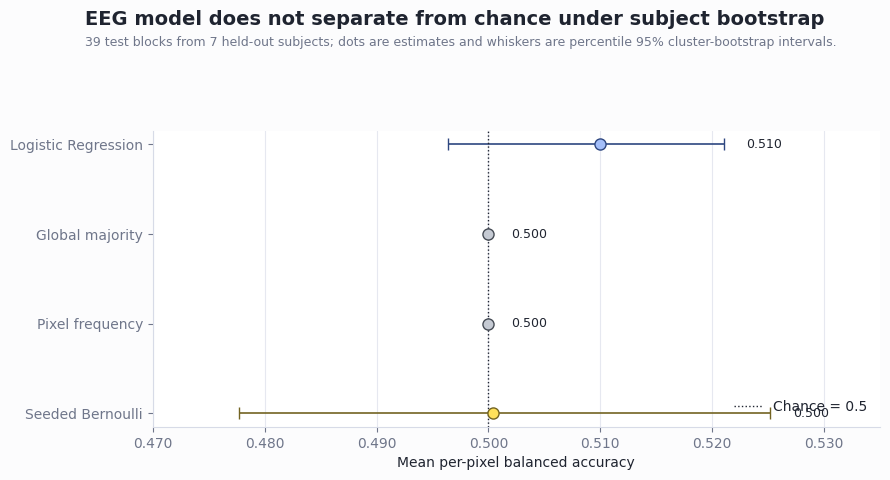

In [4]:
plot_df = metrics_df.reset_index().iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [
    COLORS["gold"] if name == "Seeded Bernoulli" else
    COLORS["blue"] if name == "Logistic Regression" else
    COLORS["neutral"]
    for name in plot_df["model"]
]
edge_colors = [
    COLORS["gold_dark"] if name == "Seeded Bernoulli" else
    COLORS["blue_dark"] if name == "Logistic Regression" else
    COLORS["neutral_dark"]
    for name in plot_df["model"]
]

for y_position, (_, row), face, edge in zip(range(len(plot_df)), plot_df.iterrows(), colors, edge_colors):
    estimate = row["mean_balanced_accuracy"]
    ax.errorbar(
        estimate,
        y_position,
        xerr=[[estimate - row["ci_lower"]], [row["ci_upper"] - estimate]],
        fmt="o",
        markersize=8,
        color=edge,
        markerfacecolor=face,
        markeredgecolor=edge,
        capsize=4,
        linewidth=1.2,
    )
    ax.text(row["ci_upper"] + 0.002, y_position, f"{estimate:.3f}", va="center", fontsize=9)

ax.axvline(0.5, color=COLORS["ink"], linestyle=":", linewidth=1.0, label="Chance = 0.5")
ax.set_yticks(range(len(plot_df)), plot_df["model"])
ax.set_xlabel("Mean per-pixel balanced accuracy")
ax.set_xlim(0.47, 0.535)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8)
ax.legend(frameon=False, loc="lower right")
add_header(
    fig,
    "EEG model does not separate from chance under subject bootstrap",
    "39 test blocks from 7 held-out subjects; dots are estimates and whiskers are percentile 95% cluster-bootstrap intervals.",
)
finish_figure(fig)


### 4. Train-only screening and selection optimism

Screening chose one common feature family before any outer-test feature was loaded. The second panel compares each pixel's selected inner-CV score with its one-time outer-test balanced accuracy.


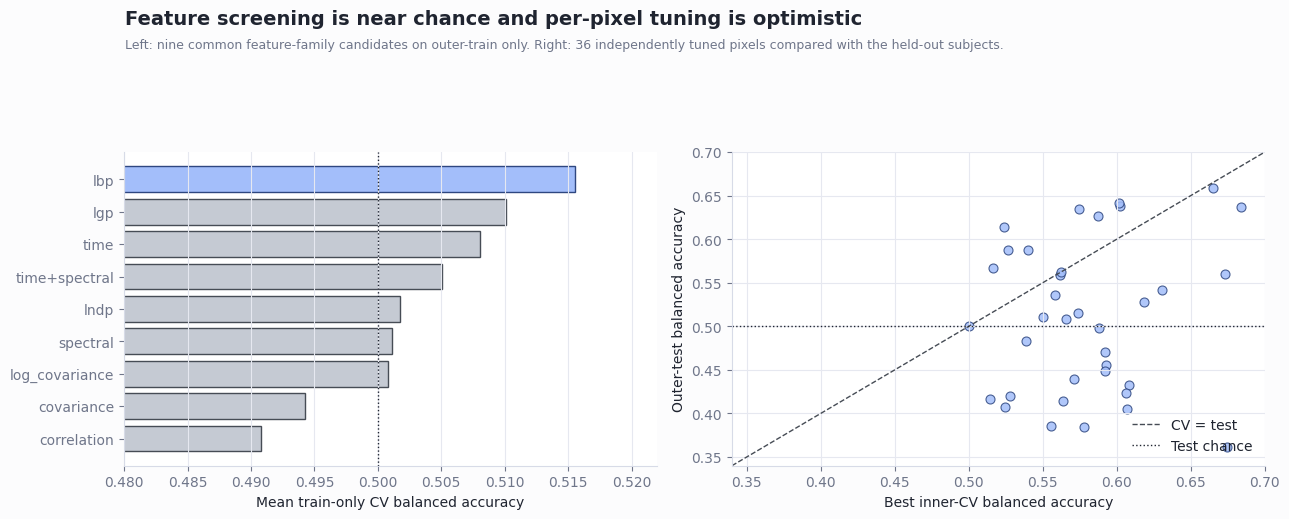

In [5]:
screening_df = pd.DataFrame(
    {
        "feature_family": ["+".join(candidate["block_names"]) for candidate in run.screening["candidates"]],
        "mean_cv_balanced_accuracy": [candidate["mean_score"] for candidate in run.screening["candidates"]],
    }
).sort_values("mean_cv_balanced_accuracy")

model_df = pd.DataFrame(
    {
        "pixel_index": [model["pixel_index"] for model in run.results["models"]],
        "pixel_name": [model["pixel_name"] for model in run.results["models"]],
        "best_cv_balanced_accuracy": [model["best_cv_score"] for model in run.results["models"]],
        "test_balanced_accuracy": run.test_balanced_accuracy,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
bar_colors = [COLORS["blue"] if name == "lbp" else COLORS["neutral"] for name in screening_df["feature_family"]]
bar_edges = [COLORS["blue_dark"] if name == "lbp" else COLORS["neutral_dark"] for name in screening_df["feature_family"]]
axes[0].barh(screening_df["feature_family"], screening_df["mean_cv_balanced_accuracy"], color=bar_colors, edgecolor=bar_edges)
axes[0].axvline(0.5, color=COLORS["ink"], linestyle=":", linewidth=1.0)
axes[0].set_xlabel("Mean train-only CV balanced accuracy")
axes[0].set_xlim(0.48, 0.522)
axes[0].grid(axis="x", color=COLORS["grid"], linewidth=0.8)

axes[1].scatter(
    model_df["best_cv_balanced_accuracy"],
    model_df["test_balanced_accuracy"],
    s=42,
    color=COLORS["blue"],
    edgecolor=COLORS["blue_dark"],
    linewidth=0.8,
    alpha=0.85,
)
limits = (0.34, 0.70)
axes[1].plot(limits, limits, color=COLORS["neutral_dark"], linestyle="--", linewidth=1.0, label="CV = test")
axes[1].axhline(0.5, color=COLORS["ink"], linestyle=":", linewidth=1.0, label="Test chance")
axes[1].set_xlim(limits)
axes[1].set_ylim(limits)
axes[1].set_xlabel("Best inner-CV balanced accuracy")
axes[1].set_ylabel("Outer-test balanced accuracy")
axes[1].grid(color=COLORS["grid"], linewidth=0.8)
axes[1].legend(frameon=False, loc="lower right")

add_header(
    fig,
    "Feature screening is near chance and per-pixel tuning is optimistic",
    "Left: nine common feature-family candidates on outer-train only. Right: 36 independently tuned pixels compared with the held-out subjects.",
)
finish_figure(fig, top=0.82)


### 5. Spatial distribution of per-pixel performance

The 6x6 heatmap preserves the row-major target layout. Values above and below 0.5 are scattered rather than forming a coherent reconstructed region.


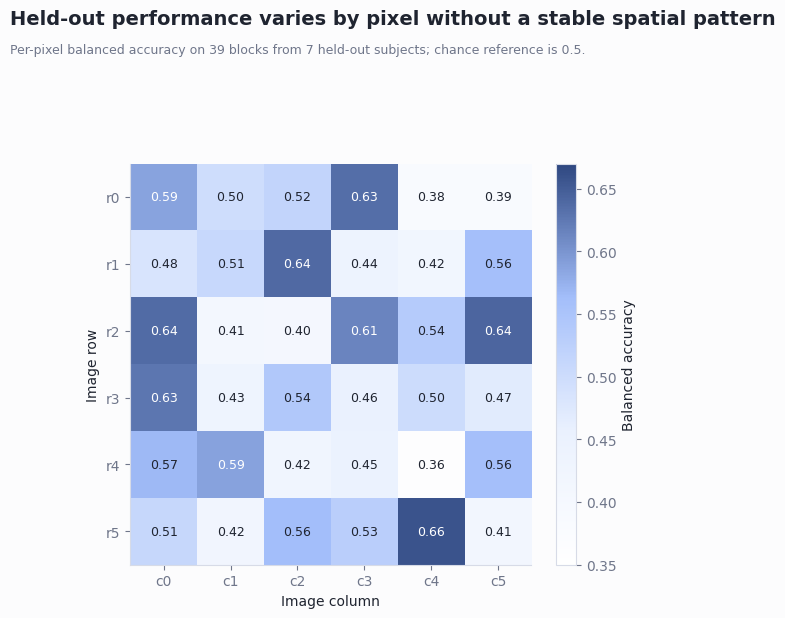

In [6]:
pixel_matrix = evaluations["Logistic Regression"].per_pixel_balanced_accuracy.reshape(6, 6)
heatmap_cmap = LinearSegmentedColormap.from_list(
    "balanced_accuracy",
    [COLORS["panel"], "#EAF1FE", COLORS["blue"], COLORS["blue_dark"]],
)
fig, ax = plt.subplots(figsize=(7.2, 6.2))
image = ax.imshow(pixel_matrix, cmap=heatmap_cmap, vmin=0.35, vmax=0.67)
for row in range(6):
    for column in range(6):
        value = pixel_matrix[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=COLORS["panel"] if value > 0.58 else COLORS["ink"],
        )
ax.set_xticks(range(6), [f"c{column}" for column in range(6)])
ax.set_yticks(range(6), [f"r{row}" for row in range(6)])
ax.set_xlabel("Image column")
ax.set_ylabel("Image row")
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Balanced accuracy")
add_header(
    fig,
    "Held-out performance varies by pixel without a stable spatial pattern",
    "Per-pixel balanced accuracy on 39 blocks from 7 held-out subjects; chance reference is 0.5.",
)
finish_figure(fig, top=0.82)


### 6. Reconstruction examples

Examples are selected deterministically by minimum, median-nearest, and maximum Hamming distance. Probability maps show the 36 independent classifier outputs before the fixed 0.5 threshold.


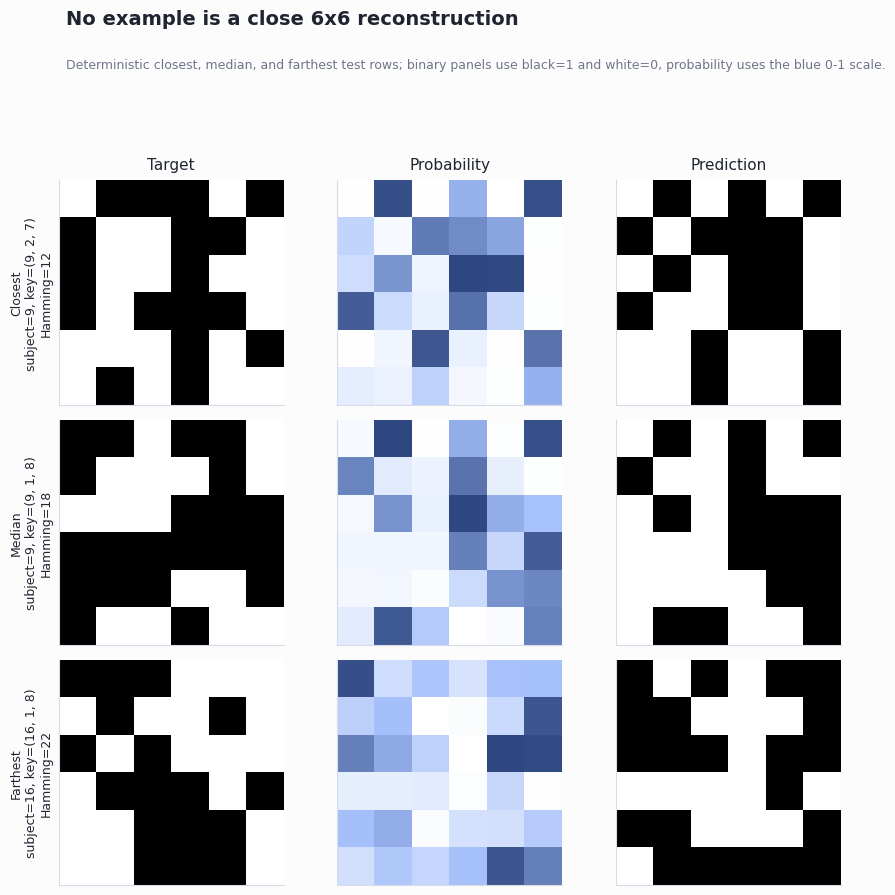

In [7]:
row_hamming = np.count_nonzero(run.test_targets != run.predictions, axis=1)
median_value = float(np.median(row_hamming))
example_indices = [
    int(np.argmin(row_hamming)),
    int(np.argmin(np.abs(row_hamming - median_value))),
    int(np.argmax(row_hamming)),
]
example_labels = ["Closest", "Median", "Farthest"]
probability_cmap = LinearSegmentedColormap.from_list(
    "probability",
    [COLORS["panel"], "#EAF1FE", COLORS["blue"], COLORS["blue_dark"]],
)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row_position, (example_label, sample_index) in enumerate(zip(example_labels, example_indices)):
    matrices = (
        run.test_targets[sample_index].reshape(6, 6),
        run.probabilities[sample_index].reshape(6, 6),
        run.predictions[sample_index].reshape(6, 6),
    )
    for column_position, matrix in enumerate(matrices):
        cmap = probability_cmap if column_position == 1 else "Greys"
        axes[row_position, column_position].imshow(matrix, cmap=cmap, vmin=0, vmax=1)
        axes[row_position, column_position].set_xticks([])
        axes[row_position, column_position].set_yticks([])
    key = tuple(run.split["test_sample_keys"][sample_index])
    axes[row_position, 0].set_ylabel(
        f"{example_label}\nsubject={run.test_subject_ids[sample_index]}, key={key}\nHamming={row_hamming[sample_index]}",
        fontsize=9,
    )

for column_position, title in enumerate(("Target", "Probability", "Prediction")):
    axes[0, column_position].set_title(title, fontsize=11, pad=8)

add_header(
    fig,
    "No example is a close 6x6 reconstruction",
    "Deterministic closest, median, and farthest test rows; binary panels use black=1 and white=0, probability uses the blue 0-1 scale.",
)
finish_figure(fig, top=0.88)


### 7. LBP feature interpretation

Coefficients belong to standardized, independently regularized per-pixel models. Selection frequency and absolute coefficient magnitude are therefore descriptive stability diagnostics, **not** physiological channel importance or causal evidence.


,channel,selection_count,selected_pixels,mean_abs_standardized_coefficient
50,P8,104,24,0.0695
59,TP10,100,24,0.0933
62,TP9,97,25,0.1329
31,FC6,96,25,0.1086
43,P1,94,28,0.0998
38,Fz,93,23,0.1187
37,Fp2,92,25,0.1019
49,P7,88,25,0.1374
21,F4,88,27,0.1242
19,F2,87,24,0.1310


,code,selection_count,mean_abs_coefficient
159,code_175,38,0.1504
104,code_113,35,0.1317
38,code_040,34,0.0844
176,code_193,33,0.1647
78,code_081,33,0.1593
207,code_225,33,0.1307
0,code_000,33,0.0538
236,code_255,33,0.0303
122,code_131,31,0.1736
210,code_228,31,0.1690


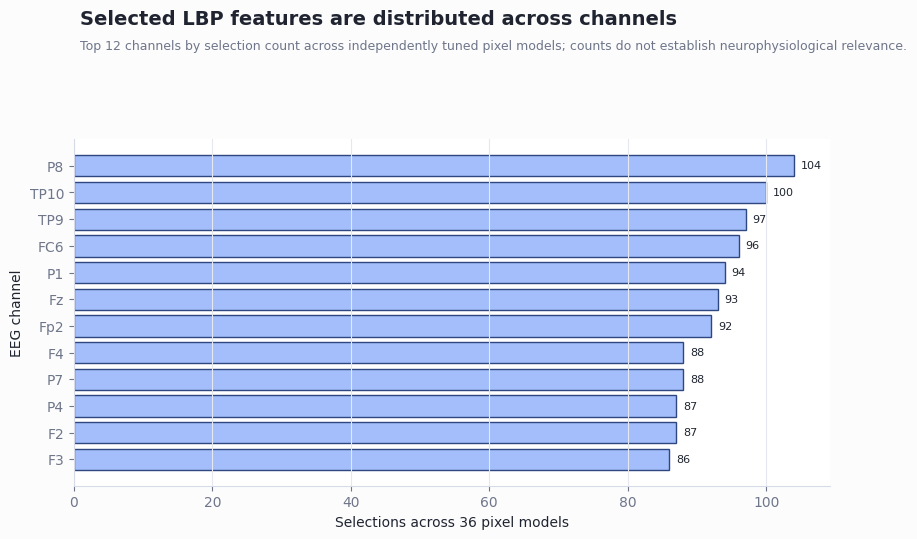

In [8]:
feature_rows = []
for model in run.results["models"]:
    for feature_name, coefficient in zip(model["selected_feature_names"], model["coefficients"]):
        block, channel, code = feature_name.split(":")
        feature_rows.append({
            "pixel_index": model["pixel_index"],
            "block": block,
            "channel": channel,
            "code": code,
            "coefficient": coefficient,
            "abs_coefficient": abs(coefficient),
        })
feature_df = pd.DataFrame(feature_rows)
channel_summary = (
    feature_df.groupby("channel", as_index=False)
    .agg(
        selection_count=("coefficient", "size"),
        selected_pixels=("pixel_index", "nunique"),
        mean_abs_standardized_coefficient=("abs_coefficient", "mean"),
    )
    .sort_values(["selection_count", "mean_abs_standardized_coefficient"], ascending=False)
)
code_summary = (
    feature_df.groupby("code", as_index=False)
    .agg(selection_count=("coefficient", "size"), mean_abs_coefficient=("abs_coefficient", "mean"))
    .sort_values(["selection_count", "mean_abs_coefficient"], ascending=False)
)

display(channel_summary.head(12).round(4))
display(code_summary.head(10).round(4))

top_channels = channel_summary.head(12).sort_values("selection_count")
fig, ax = plt.subplots(figsize=(8.5, 5.4))
ax.barh(
    top_channels["channel"],
    top_channels["selection_count"],
    color=COLORS["blue"],
    edgecolor=COLORS["blue_dark"],
)
for y_position, value in enumerate(top_channels["selection_count"]):
    ax.text(value + 1, y_position, str(int(value)), va="center", fontsize=8)
ax.set_xlabel("Selections across 36 pixel models")
ax.set_ylabel("EEG channel")
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8)
add_header(
    fig,
    "Selected LBP features are distributed across channels",
    "Top 12 channels by selection count across independently tuned pixel models; counts do not establish neurophysiological relevance.",
)
finish_figure(fig)


## Takeaways

1. **Primary result:** mean per-pixel balanced accuracy is 0.5100 with 95% subject-bootstrap interval [0.4964, 0.5211]. The interval includes chance.
2. **Reconstruction overlap:** mean sample IoU is 0.3353 and global micro IoU is 0.3346. These are descriptive held-out reconstruction metrics and do not affect feature screening or hyperparameter selection.
3. **Baselines:** the EEG model does not dominate simple non-EEG references. Pixel-frequency prediction has lower Hamming loss (0.4758 vs 0.4858), lower mean Hamming distance (17.13 vs 17.49), and substantially lower Brier score (0.2505 vs 0.3340).
4. **Selection optimism:** mean best inner-CV balanced accuracy is about 0.579, roughly 0.069 above held-out performance.
5. **Reconstruction:** exact-match accuracy is zero for every evaluated method. The result does not support successful cross-subject image reconstruction.
6. **Limits:** only seven test subjects are available, the source EEG amplitude scale remains unresolved, and the stored artifact records a dirty Git worktree. Thesis reporting should retain the negative conclusion and point to a committed code revision.


In [9]:
model_metrics = evaluations["Logistic Regression"]
model_interval = bootstrap_intervals["Logistic Regression"]
assert model_interval.lower <= 0.5 <= model_interval.upper
assert model_metrics.exact_match_accuracy == 0.0
assert model_metrics.mean_balanced_accuracy == np.mean(run.test_balanced_accuracy)
np.testing.assert_allclose(model_metrics.mean_sample_iou, 0.335257970, atol=5e-10)
np.testing.assert_allclose(model_metrics.micro_iou, 0.334634146, atol=5e-10)
np.testing.assert_allclose(model_metrics.hamming_loss, 0.485754986, atol=5e-10)
assert np.allclose(metrics_df["hamming_loss"], 1.0 - metrics_df["bit_accuracy"])
assert np.allclose(metrics_df["hamming_loss"], metrics_df["mean_hamming_distance"] / 36.0)
assert metrics_df.loc["Pixel frequency", "bit_accuracy"] > metrics_df.loc["Logistic Regression", "bit_accuracy"]
assert metrics_df.loc["Pixel frequency", "brier_score"] < metrics_df.loc["Logistic Regression", "brier_score"]
assert all(interval.n_resamples == run.config.bootstrap_iterations for interval in bootstrap_intervals.values())
print("LOGISTIC_REGRESSION_RANDOM_PIXELS_VERIFIED")


LOGISTIC_REGRESSION_RANDOM_PIXELS_VERIFIED
